Evaluation Graphs for ANN

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_default_data_paths, split_train_test

data_dir = ROOT / 'src' / 'data'
paths = collect_default_data_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 20 SCADA files
Train files: 14 | Test files: 6


In [ ]:
# confusion matrix for event detection
history = 5
epochs = 12
batch_size = 256
learning_rate = 1e-3

baseline_hidden_sizes = (64, 32)
detector = build_detector(
    train_paths,
    history=history,
    epochs=epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    hidden_sizes=baseline_hidden_sizes,
)

# train_results = [detector.detect(path) for path in train_paths[:3]]
# test_results = [detector.detect(path) for path in test_paths[:3]]

disp = detector.prediction_confusion_matrix(test_paths[1])

In [ ]:
from src.event_detection_pipeline.model_io import save_detector

# Or save to nested directories (will create them automatically)
save_detector(detector, directory="../results/2026-06-29/detector_2l_smaller")

✓ Model weights saved to ../results/2026-06-29/detector_baseline/model_weights.pth
✓ Scalers saved to ../results/2026-06-29/detector_baseline/scalers.pkl
✓ Threshold config saved to ../results/2026-06-29/detector_baseline/threshold.pkl
✓ Metadata saved to ../results/2026-06-29/detector_baseline/metadata.pkl

✓ All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_baseline/


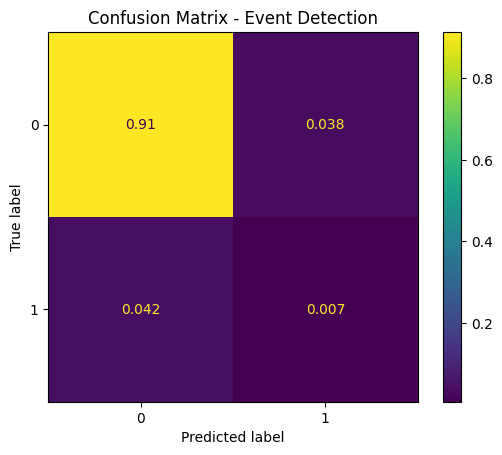

In [4]:
disp.plot()
plt.title('Confusion Matrix - Event Detection')
plt.show()


In [ ]:
from src.event_detection_pipeline.model_io import load_detector
detector = load_detector(directory="../results/2026-06-29/detector_2l_smaller", device="mps")

✓ Metadata loaded from ../results/2026-06-29/detector_baseline/metadata.pkl
✓ Scalers loaded from ../results/2026-06-29/detector_baseline/scalers.pkl
✓ Threshold config loaded from ../results/2026-06-29/detector_baseline/threshold.pkl
✓ Model weights loaded from ../results/2026-06-29/detector_baseline/model_weights.pth

✓ Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_baseline/


{'precision': 0.15555555555555556, 'accuracy': 0.9203187250996016, 'probability_of_detection': 0.14285714285714285, 'recall': 0.14285714285714285, 'false_alarm_rate': 0.039790575916230364, 'detection_latency_seconds': -158400.0, 'alarms': 45}


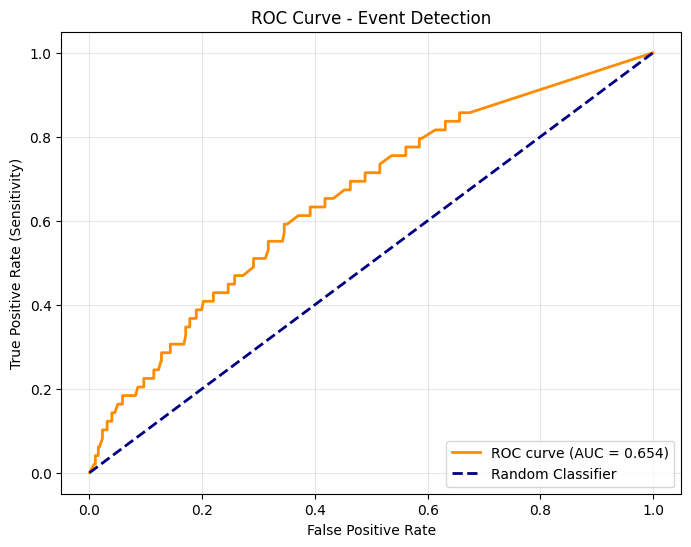

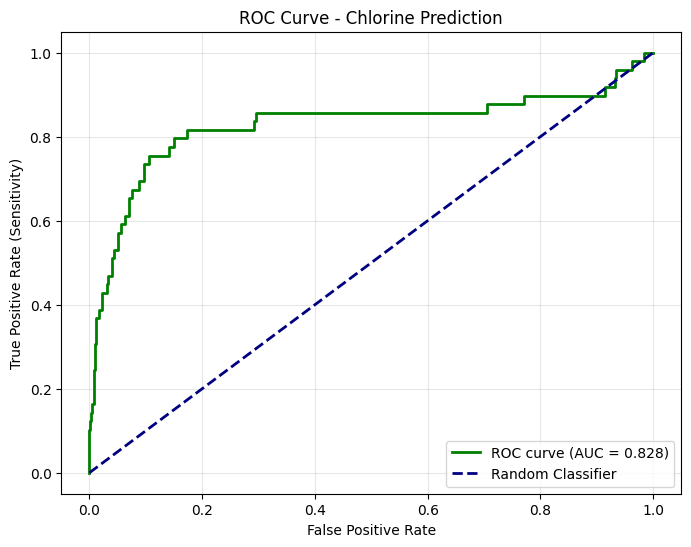

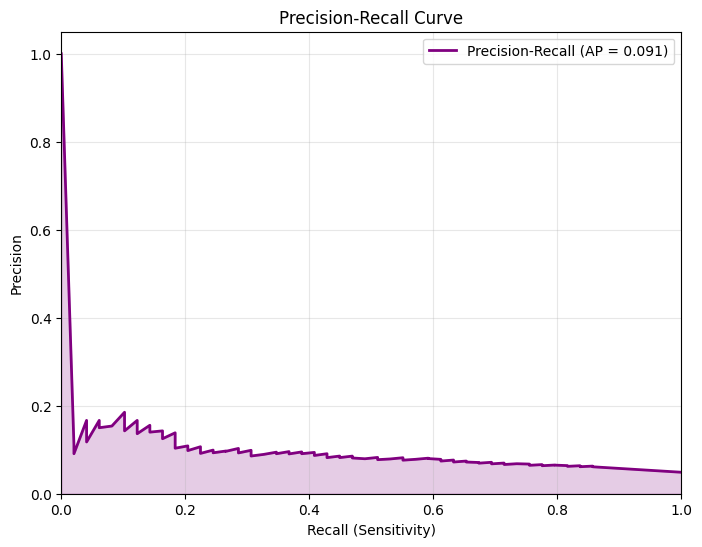

In [6]:
from src.event_detection_pipeline.evaluation import (
    plot_roc_curve_event_detection,
    plot_roc_curve_chlorine_prediction,
    plot_precision_recall_curve,
)
import matplotlib.pyplot as plt

results = detector.detect(test_paths[1])

# Get summary metrics
summary = results.summary()
print(summary)

# Plot ROC curve for event detection
fpr, tpr, auc, fig, ax = plot_roc_curve_event_detection(results)
plt.show()

# Plot ROC curve for chlorine (if you know chlorine indices)
fpr_cl, tpr_cl, auc_cl, fig_cl, ax_cl = plot_roc_curve_chlorine_prediction(
    results, 
    chlorine_indices=[0, 1, 2]  # adjust to your chlorine sensor indices
)
plt.show()

# Precision-Recall curve
precision, recall, f1_scores, fig, ax = plot_precision_recall_curve(results)
plt.show()